In [1]:
import platform
if 'mac' in platform.platform():
    BASE_DIR = "/Users/USER/vrtopc/"
    DATA_DIR = "/media/data/vrtopc"
else:
    BASE_DIR = "/home/USER/vr_to_pc/"
    DATA_DIR = "/media/data/vrtopc"

import sys
sys.path.append(BASE_DIR)

In [2]:
POS_DECODING_PERC_TRAIN = 0.5

LABELS_DEV = ['crawl', 'walk', 'run', 'adult']

LABELS_ROC = ['', '2s', '2.5s', '3s']

### Imports

In [3]:
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

from utils.metrics import get_spatial_correlation

import numpy as np
import scipy
import pandas as pd
import os
import copy
import re
import yaml

import matplotlib.pyplot as plt

# Processed data for the Science and Muessig papers

### Parameters

In [5]:
from utils.spatial_units import RateMaps, PolarMaps

N_SAMPLES_POS = RateMaps.N_SAMPLES_POS
PLACE_SI_TH = RateMaps.PLACE_SI_TH

N_SAMPLES_THET = PolarMaps.N_SAMPLES_THET
HD_SI_TH = PolarMaps.HD_SI_TH
HD_RVL_TH = PolarMaps.HD_RVL_TH


In [ ]:
edge_n_bins = 4

ONLY_2ND_TRIAL = True

AGES_TO_REMOVE = list(range(26, 32 +1))

SAVE_PLOTS = False
SAVE_DIR = None

### Load Data

In [7]:
ratnames_science = []
ratnames_muessig = []

data_dir = os.path.join(DATA_DIR, 'real_data', 'science2010_data_struct')
data = {}
for file in os.listdir(data_dir):
    if file.endswith('.mat'):
        name = file.split('.')[0].lower()
        if 'shuffled' in name:
            name += '_science2010'
        else:
            ratnames_science.append(name)
        data[name] = scipy.io.loadmat(os.path.join(data_dir, file))

data_dir = os.path.join(DATA_DIR, 'real_data', 'muessig_data_struct')
for file in os.listdir(data_dir):
    if file.endswith('.mat'):
        name = file.split('.')[0].lower()
        if 'shuffled' in name:
            name += '_muessig'
        else:
            ratnames_muessig.append(name)
            
        if name in data.keys():
            raise ValueError(f"Duplicate file name: {name}")
        data[name] = scipy.io.loadmat(os.path.join(data_dir, file))

sorted(list(data.keys()))[:5]

['r101_p20', 'r104_p26', 'r112_p40', 'r115_p24', 'r118_p24']

In [8]:
def get(x):
    return x[0][0]

data_dict = {}
ratnames_old = []

for k in data.keys():
    print(k)

    if not k.startswith('r'):
        print(f"File name {k} does not start with 'r', skipping")
        continue

    ratname = k
    
    if ratname not in data_dict.keys():
        data_dict[ratname] = {}
    
    d = get(data[k]['tmpS'])
    d_keys = list(d.dtype.names)

    dataset = d[d_keys.index('dataset')][0].split('_')[-1]
    ratnames_old.append(f"{ratname}_{dataset}")

    # sample rate is always 50 Hz
    ages = d[d_keys.index('age')][0] # age 40 denotes adult
    ages = [a if a<100 else 40 for a in ages]

    sample_rates = d[d_keys.index('sampleRate')][0]
    env_types = d[d_keys.index('envType')][0]
    ppm = d[d_keys.index('ppm')][0]
    spike_times = d[d_keys.index('spikeTimes')][0]
    is_cs_neuron = d[d_keys.index('isCSNeuron')][0]
    has_min_freq = d[d_keys.index('hasMinFreq')][0]
    pos = d[d_keys.index('positions')][0]
    hd = d[d_keys.index('directions')][0] # degrees
    speed = d[d_keys.index('speed')][0] # cm/s

    rate_maps = d[d_keys.index('rateMaps')][0]
    pos_occ = d[d_keys.index('posOccMaps')][0]
    si = d[d_keys.index('SI')][0]
    rate_maps_corr = d[d_keys.index('corrRateMaps')][0]
    si_corr = d[d_keys.index('SICorr')][0]
    rate_maps_hd8 = d[d_keys.index('rateMapsHD8')][0]
    rate_maps_hd4 = d[d_keys.index('rateMapsHD4')][0]
    
    polar_maps = d[d_keys.index('polarMaps')][0]
    si_pm = d[d_keys.index('dirSI')][0]
    rvl = d[d_keys.index('rvLength')][0]
    hd_occ = d[d_keys.index('dirOccMaps')][0]
    polar_maps_corr = d[d_keys.index('corrPolarMaps')][0]
    si_pm_corr = d[d_keys.index('dirSICorr')][0]
    rvl_corr = d[d_keys.index('rvLengthCorr')][0]
    polar_maps_pred = d[d_keys.index('predPolarMaps')][0]
    dis_ratios = d[d_keys.index('disRatios')][0]

    # there are always max 3 trials per day
    n_trials = 0
    for trial_n in range(len(ages)):
        if ONLY_2ND_TRIAL and (trial_n != 1) : continue # keep second trial

        rms = rate_maps[trial_n]
        sis = si[trial_n]
        rms_corr = rate_maps_corr[trial_n]
        sis_corr = si_corr[trial_n]
        rms_hd8 = rate_maps_hd8[trial_n]
        rms_hd4 = rate_maps_hd4[trial_n]

        pms = polar_maps[trial_n]
        sis_pm = si_pm[trial_n]
        rvls = rvl[trial_n]
        pms_corr = polar_maps_corr[trial_n]
        sis_pm_corr = si_pm_corr[trial_n]
        rvls_corr = rvl_corr[trial_n]
        drs = dis_ratios[trial_n]
        pms_pred = polar_maps_pred[trial_n]
        if rms.shape[-1] == 0 or pms.shape[-1] == 0:
            print(f"Skipping trial {trial_n} because rate maps or polar maps are empty")
            continue

        t = {}
        age = ages[trial_n]
        env = env_types[trial_n][0]
        p = pos[trial_n]
    
        if np.isnan(age) and (len(env) == 0) and (p.shape[-1] == 0):
            continue
        n_trials += 1

        age = int(age)
        if age not in data_dict[ratname].keys():
            data_dict[ratname][age] = {}
            data_dict[ratname][age]['trials'] = []

        t['name'] = n_trials
        t['environment'] = env
        t['ppm'] = ppm
        t['sample_rate'] = sample_rates[trial_n] # Hz
        t['positions'] = p
        t['x'] = p[:,0]
        t['y'] = p[:,1]
        if ratname in ratnames_science:
            t['spike_times'] = spike_times[trial_n][0]
            t['is_cs_neuron'] = is_cs_neuron[trial_n][0]
            t['has_min_freq'] = has_min_freq[trial_n][0]
        else:
            t['spike_times'] = spike_times[trial_n].squeeze() if len(spike_times[trial_n])>1 else spike_times[trial_n][0]
            t['is_cs_neuron'] = is_cs_neuron[trial_n].squeeze() if len(is_cs_neuron[trial_n])>1 else is_cs_neuron[trial_n][0]
            t['has_min_freq'] = has_min_freq[trial_n].squeeze() if len(has_min_freq[trial_n])>1 else has_min_freq[trial_n][0]

        t['speed'] = speed[trial_n].squeeze()/100 # m/s
        t['hd'] = hd[trial_n].squeeze()
        t['duration'] = len(t['x'])/t['sample_rate']

        # convert to (n_units, n_bins, n_bins)
        t['rate_maps'] = np.array([rms[idx][0] for idx in range(len(rms))])
        t['si'] = np.array([sis[idx][0] for idx in range(len(sis))])
        t['rate_maps_corr'] = np.array([rms_corr[idx][0] for idx in range(len(rms_corr))])
        t['si_corr'] = np.array([sis_corr[idx][0] for idx in range(len(sis_corr))])

        rms_hd_np8 = np.zeros((t['rate_maps'].shape[0], 8, t['rate_maps'].shape[-1], t['rate_maps'].shape[-1]))
        rms_hd_np4 = np.zeros((t['rate_maps'].shape[0], 4, t['rate_maps'].shape[-1], t['rate_maps'].shape[-1]))
        for j in range(8):
            if j < 4:
                rms_hd_np4[:, j, ...] = np.array(
                    [get(rms_hd4[idx])[j] for idx in range(len(rms_hd4))]
                )
            rms_hd_np8[:, j, ...] = np.array(
                [get(rms_hd8[idx])[j] for idx in range(len(rms_hd8))]
            )
        # convert to (n_units, 8, n_bins, n_bins)
        t['rate_maps_hd8'] = rms_hd_np8
        t['rate_maps_hd4'] = rms_hd_np4

        # convert to (n_units, n_bins)
        t['polar_maps'] = np.array([pms[idx][0] for idx in range(len(pms))])[..., 0]
        t['si_pm'] = np.array([sis_pm[idx][0] for idx in range(len(sis_pm))])
        t['rvl'] = np.array([rvls[idx][0] for idx in range(len(rvls))])
        t['polar_maps_corr'] = np.array([pms_corr[idx][0] for idx in range(len(pms_corr))])[..., 0]
        t['si_pm_corr'] = np.array([sis_pm_corr[idx][0] for idx in range(len(sis_pm_corr))])
        t['rvl_corr'] = np.array([rvls_corr[idx][0] for idx in range(len(rvls_corr))])

        t['polar_maps_pred'] = np.array([pms_pred[idx][0] for idx in range(len(pms_pred))])[..., 0]
        t['dis_ratios'] = np.array(drs[:,0])

        if t['rate_maps'].shape[0] != t['polar_maps'].shape[0]:
            raise ValueError(f"Rate maps ({t['rate_maps'].shape}) and polar maps ({t['polar_maps'].shape}) have different number of units")

        t['pos_occ'] = get(pos_occ[trial_n])
        t['hd_occ'] = np.array(hd_occ[trial_n][:,0])

        data_dict[ratname][age]['trials'].append(t)
    print(f"\t{n_trials} trial(s)")
    print()

r1308_d4
	1 trial(s)

r1526_p18
	1 trial(s)

r1343_d4
	1 trial(s)

r1526_p23
	1 trial(s)

r1343_d1
	1 trial(s)

r1589_p22
	1 trial(s)

r1589_p28
	1 trial(s)

r1333_d1
	1 trial(s)

r1477_p29
	1 trial(s)

r1552_p22
	1 trial(s)

r1637_p23
	1 trial(s)

r1588_p20
	1 trial(s)

r1589_p23
	1 trial(s)

r1589_p27
	1 trial(s)

r1588_p22
	1 trial(s)

r1515_p23
	1 trial(s)

r1589_p17
	1 trial(s)

r1589_p26
	1 trial(s)

r1552_p17
	1 trial(s)

r1308_d1
	1 trial(s)

r1526_p20
	1 trial(s)

r1589_p21
	1 trial(s)

r1552_p16_1
	1 trial(s)

r1589_p25
	1 trial(s)

r1333_d2
	1 trial(s)

r1628_p22_ca1
	1 trial(s)

r1589_p19
	1 trial(s)

r1515_p22
	1 trial(s)

r1526_p21
	1 trial(s)

r1588_p24
	1 trial(s)

r1474_p25
	1 trial(s)

r1552_p16_2
	1 trial(s)

r1588_p16
	1 trial(s)

shuffled_metrics_science2010
File name shuffled_metrics_science2010 does not start with 'r', skipping
shuffled_metrics_adult_science2010
File name shuffled_metrics_adult_science2010 does not start with 'r', skipping
r1588_p21
	1 trial(s)



In [9]:
ages = []
print('--------------------------------')
for k, v in data_dict.items():
    print(k)
    ages_tmp = list(v.keys())
    print('ages', ages_tmp)
    ages += ages_tmp
    print()
    print('--------------------------------')

--------------------------------
r1308_d4
ages [40]

--------------------------------
r1526_p18
ages [18]

--------------------------------
r1343_d4
ages [40]

--------------------------------
r1526_p23
ages [23]

--------------------------------
r1343_d1
ages [40]

--------------------------------
r1589_p22
ages [22]

--------------------------------
r1589_p28
ages [28]

--------------------------------
r1333_d1
ages [40]

--------------------------------
r1477_p29
ages [29]

--------------------------------
r1552_p22
ages [22]

--------------------------------
r1637_p23
ages [23]

--------------------------------
r1588_p20
ages [20]

--------------------------------
r1589_p23
ages [23]

--------------------------------
r1589_p27
ages [27]

--------------------------------
r1588_p22
ages [22]

--------------------------------
r1515_p23
ages [23]

--------------------------------
r1589_p17
ages [17]

--------------------------------
r1589_p26
ages [26]

--------------------------------

### Shuffled Threshold Extraction

In [10]:
metrics_shuffle_th_science = {}
metrics_shuffle_th_muessig = {}

for filename in data.keys():
    if not filename.startswith('shuffled'):
        continue
    print(filename)

    shuffled_si = data[filename]['shuffledSIByAge']
    shuffled_si_pm = data[filename]['shuffledDirSIByAge']
    shuffled_rvl = data[filename]['shuffledRVLByAge']
    for idx in range(len(shuffled_si)):
        for m, k in zip([shuffled_si, shuffled_si_pm, shuffled_rvl], ['SI', 'dirSI', 'rvLength']):
            m_curr = get(m[idx][0])
            keys = list(m_curr.dtype.names)
            age_group = get(m_curr[keys.index('ageGroup')])
            th = get(m_curr[keys.index(k+'Threshold')])

            if 'science' in filename.lower():
                if k not in metrics_shuffle_th_science.keys():
                    metrics_shuffle_th_science[k] = {}

                age = 14+age_group*2
                if age != 100:
                    metrics_shuffle_th_science[k][age] = th
                    metrics_shuffle_th_science[k][age+1] = th
                else : metrics_shuffle_th_science[k][40] = th
            elif 'muessig' in filename.lower():
                if k not in metrics_shuffle_th_muessig.keys():
                    metrics_shuffle_th_muessig[k] = {}

                age = 14+age_group*2
                if age != 100:
                    metrics_shuffle_th_muessig[k][age] = th
                    metrics_shuffle_th_muessig[k][age+1] = th
                else : metrics_shuffle_th_muessig[k][40] = th


shuffled_metrics_science2010
shuffled_metrics_adult_science2010
shuffled_metrics_muessig


### Activity Extraction

A neuron is considered actually tuned to direction if its corrected polar map still passes the criterion for inclusion (RVL or KLD)

and its Pearson correlation with the uncorrected polar map is higher than 0.5

In [11]:
def normalize_rate_maps(rate_maps):
    # normalize rate maps
    rate_maps_min = np.moveaxis(
        np.tile(np.nanmin(rate_maps, axis=(1,2)), (N_SAMPLES_POS, N_SAMPLES_POS, 1)), -1, 0
    )
    rate_maps_max = np.moveaxis(
        np.tile(np.nanmax(rate_maps, axis=(1,2)), (N_SAMPLES_POS, N_SAMPLES_POS, 1)), -1, 0
    )
    rate_maps = (
        (rate_maps - rate_maps_min) / (rate_maps_max - rate_maps_min)
    )
    return rate_maps

In [12]:
from utils.spatial_units import RateMaps, PolarMaps

place_units = RateMaps(positions=None, env_dim=0)
hd_units = PolarMaps(thetas=None)

data_dict_age = {}
perc_kept = []

for k, v in sorted(data_dict.items()):
    print(f"Rat {k}")
    if k in ratnames_science:
        metrics_shuffle_th = metrics_shuffle_th_science
    elif k in ratnames_muessig:
        metrics_shuffle_th = metrics_shuffle_th_muessig
    else:
        raise ValueError(f"Rat {k} not found in science or muessig data")
    
    for age in sorted(v.keys()):
        if age in AGES_TO_REMOVE:
            print(f"\tAge {age} in ages to remove, skipping")
            continue
        
        exp = v[age] # get the experiment for this rat's age
        print(f"\tAge {age}")
        if (age in data_dict_age.keys()) and (k in data_dict_age[age].keys()):
            print(f"\tSkipping because already processed")
            continue

        if age not in data_dict_age.keys(): # initialize all dict if first exp for this age
            data_dict_age[age] = {}
        
        data_dict_age[age][k] = {}
        for k_tmp in [
            'positions', 'hd', 'speed', 'spike_times', 'sample_rate',
            'rate_maps', 'pos_occ', 'rate_maps_corr',
            'si_matlab', 'si_corr_matlab', 'si_rm', 'si_rm_corr',
            'selected_place_units', 'n_fields',
            'single_field_dim', 'pu_flipped', 'pu_field_flipped',
            'rate_maps_hd8', 'rate_maps_hd4',
            'polar_maps', 'hd_occ', 'polar_maps_corr',
            'si_pm_matlab', 'rvl_matlab', 'si_pm', 'rvl_pm', 'si_pm_corr_matlab', 'rvl_corr_matlab',
            'rvl_pm_corr', 'rvangle_pm', 'rvangle_pm_corr',
            'selected_hd_units', 'selected_place_hd_units',
            'polar_maps_pred', 'dis_ratios',
            'trial_start_idx'
        ]:
            data_dict_age[age][k][k_tmp] = []

        rate_maps_all = []
        polar_maps_all = []
        indices_to_keep = None
        trial_start_idx = 0
        for trial in exp['trials']:
            if trial['environment'] != 'hp' and trial['environment'] != 'fam':
                raise ValueError(f"\tEnvironment is {trial['environment']} instead of hp or fam")

            rate_maps = trial['rate_maps']
            if rate_maps.shape[1] != N_SAMPLES_POS or rate_maps.shape[2] != N_SAMPLES_POS:
                raise ValueError(f"\t\tRate maps shape is {rate_maps.shape} instead of (n_cells, {N_SAMPLES_POS}, {N_SAMPLES_POS})")
            rate_maps_all.append(rate_maps.copy())

            si_matlab = trial['si']
            rate_maps_corr = trial['rate_maps_corr']
            si_corr_matlab = trial['si_corr']
            rate_maps_hd8 = trial['rate_maps_hd8']
            rate_maps_hd4 = trial['rate_maps_hd4']

            pos_occ = trial['pos_occ']

            polar_maps = trial['polar_maps']
            if polar_maps.shape[1] != N_SAMPLES_THET:
                raise ValueError(f"\t\Polar maps shape is {polar_maps.shape} instead of (n_cells, {N_SAMPLES_THET})")
            polar_maps_all.append(polar_maps.copy())

            si_pm_matlab = trial['si_pm']
            rvl_matlab = trial['rvl']
            polar_maps_corr = trial['polar_maps_corr']
            si_pm_corr_matlab = trial['si_pm_corr']
            rvl_corr_matlab = trial['rvl_corr']
            polar_maps_pred = trial['polar_maps_pred']
            dis_ratios = trial['dis_ratios']

            hd_occ = trial['hd_occ']

            print(f"\t(n_cells, n_samples_pos, n_samples_pos): {rate_maps.shape}")
            print(f"\t(n_cells, N_SAMPLES_THET): {polar_maps.shape}")

            # keep only Complex Spike neurons
            idx_to_keep = np.logical_and(
                trial['is_cs_neuron'] == 1, trial['has_min_freq'] == 1
            )
            if isinstance(idx_to_keep, np.bool) : idx_to_keep = np.array([idx_to_keep])
            assert len(idx_to_keep) == rate_maps.shape[0]
            idx_to_keep = np.where(idx_to_keep)[0] # convert mask to indices
            if len(idx_to_keep) == 0:
                print(f"\tSkipping trial because all rate maps are uniform")
                continue

            positions = trial['positions']
            hd = trial['hd'].astype(np.float64)
            speed = trial['speed']
            spike_times = trial['spike_times']
            sample_rate = trial['sample_rate']
            
            perc_kept.append(len(idx_to_keep)/rate_maps.shape[0]*100)
            rate_maps = rate_maps[idx_to_keep]
            si_matlab = si_matlab[idx_to_keep]
            rate_maps_corr = rate_maps_corr[idx_to_keep]
            si_corr_matlab = si_corr_matlab[idx_to_keep]
            rate_maps_hd8 = rate_maps_hd8[idx_to_keep]
            rate_maps_hd4 = rate_maps_hd4[idx_to_keep]

            polar_maps = polar_maps[idx_to_keep]
            si_pm_matlab = si_pm_matlab[idx_to_keep]
            rvl_matlab = rvl_matlab[idx_to_keep]
            polar_maps_corr = polar_maps_corr[idx_to_keep]
            si_pm_corr_matlab = si_pm_corr_matlab[idx_to_keep]
            rvl_corr_matlab = rvl_corr_matlab[idx_to_keep]
            polar_maps_pred = polar_maps_pred[idx_to_keep]
            dis_ratios = dis_ratios[idx_to_keep]

            if indices_to_keep is None: indices_to_keep = idx_to_keep
            else: indices_to_keep = np.intersect1d(indices_to_keep, idx_to_keep)
            
            rate_maps_unnorm = rate_maps.copy()
            rate_maps_corr_unnorm = rate_maps_corr.copy()
            rate_maps = normalize_rate_maps(rate_maps)
            rate_maps_corr = normalize_rate_maps(rate_maps_corr)
            
            si_rm = place_units.calculate_metrics(rate_maps, pos_occ)
            si_rm_corr = place_units.calculate_metrics(rate_maps_corr, pos_occ)
            
            n_fields, rm_fields = place_units.rate_maps_field_detection(rate_maps, rate_maps, rate_maps)

            selected_place_units = place_units.get_place_cells_indices(rate_maps, si_matlab)

            if len(selected_place_units) > 0:
                single_field_dim = np.array([
                    np.sum(np.nansum(np.array(fields), axis=0)>0) for i, fields in enumerate(rm_fields)
                    if fields and i in selected_place_units
                ])
                pu_flipped = place_units.rm_flipped(rate_maps, filter_indices=selected_place_units)

                rm_fields_selected = [f for i, f in enumerate(rm_fields) if (i in selected_place_units) and n_fields[i] > 0]
                if len(rm_fields_selected) == 0:
                    print(f"\tSkipping avg rate map field because no selected fields")
                    continue
                pu_field_flipped = place_units.rm_field_flipped(rm_fields_selected)

                for k_tmp in ['single_field_dim', 'pu_flipped', 'pu_field_flipped']:
                    data_dict_age[age][k][k_tmp].append(locals()[k_tmp])
            
            si_pm, rvl_pm, rvangle_pm = hd_units.calculate_metrics(polar_maps.copy(), hd_occ)
            _, rvl_pm_corr, rvangle_pm_corr = hd_units.calculate_metrics(polar_maps_corr.copy(), hd_occ)

            selected_hd_units = np.array([
                idx for idx in range(polar_maps.shape[0]) if
                (not np.isnan(si_pm_matlab[idx])) and (not np.isnan(rvl_matlab[idx])) and
                (not np.isnan(si_pm_corr_matlab[idx])) and (not np.isnan(rvl_corr_matlab[idx])) and
                ((si_pm_matlab[idx] > metrics_shuffle_th['dirSI'][age]) or (rvl_matlab[idx] > metrics_shuffle_th['rvLength'][age])) and
                ((si_pm_corr_matlab[idx] > metrics_shuffle_th['dirSI'][age]) or (rvl_corr_matlab[idx] > metrics_shuffle_th['rvLength'][age])) and
                (get_spatial_correlation(polar_maps[idx], polar_maps_corr[idx], return_pvalue=False) > 0.5)# and
            ], dtype=np.int32)

            selected_place_hd_units = np.intersect1d(selected_place_units, selected_hd_units, assume_unique=True)
            selected_place_units = np.setdiff1d(selected_place_units, selected_place_hd_units, assume_unique=True)
            selected_hd_units = np.setdiff1d(selected_hd_units, selected_place_hd_units, assume_unique=True)
            
            selected_place_units += trial_start_idx
            selected_hd_units += trial_start_idx
            selected_place_hd_units += trial_start_idx

            for k_tmp in [
                'positions', 'hd', 'speed', 'spike_times', 'sample_rate',
                'rate_maps', 'rate_maps_corr', 'pos_occ',
                'si_matlab', 'si_corr_matlab', 'si_rm', 'si_rm_corr',
                'selected_place_units', 'n_fields',
                'rate_maps_hd8', 'rate_maps_hd4',
                'polar_maps', 'polar_maps_corr', 'hd_occ',
                'si_pm_matlab', 'rvl_matlab', 'si_pm', 'rvl_pm', 'si_pm_corr_matlab', 'rvl_corr_matlab',
                'rvl_pm_corr', 'rvangle_pm', 'rvangle_pm_corr',
                'selected_hd_units', 'selected_place_hd_units',
                'polar_maps_pred', 'dis_ratios',
                'trial_start_idx'
            ]:
                data_dict_age[age][k][k_tmp].append(locals()[k_tmp])

            trial_start_idx += len(idx_to_keep)

        if trial_start_idx == 0:
            data_dict_age[age].pop(k)
        else:

            for k_tmp in [
                'rate_maps', 'rate_maps_corr', 'pos_occ',
                'si_matlab', 'si_corr_matlab', 'si_rm', 'si_rm_corr',
                'selected_place_units', 'n_fields',
                'rate_maps_hd8', 'rate_maps_hd4',
                'polar_maps', 'polar_maps_corr', 'hd_occ',
                'si_pm_matlab', 'rvl_matlab', 'si_pm', 'rvl_pm', 'si_pm_corr_matlab', 'rvl_corr_matlab',
                'rvl_pm_corr', 'rvangle_pm', 'rvangle_pm_corr',
                'selected_hd_units', 'selected_place_hd_units',
                'polar_maps_pred', 'dis_ratios',
            ]:
                try:
                    data_dict_age[age][k][k_tmp] = np.concatenate(data_dict_age[age][k][k_tmp])
                except ValueError as e:
                    if "zero-dimensional" in str(e):
                        data_dict_age[age][k][k_tmp] = np.array(data_dict_age[age][k][k_tmp])
                    elif "need at least one" in str(e):
                        continue
                    else:
                        raise e
            
    print(flush=True)

Rat r101_p20
	Age 20
	(n_cells, n_samples_pos, n_samples_pos): (8, 25, 25)
	(n_cells, N_SAMPLES_THET): (8, 60)


Rat r104_p26
	Age 26 in ages to remove, skipping



Rat r112_p40
	Age 40
	(n_cells, n_samples_pos, n_samples_pos): (27, 25, 25)
	(n_cells, N_SAMPLES_THET): (27, 60)


Rat r115_p24
	Age 24
	(n_cells, n_samples_pos, n_samples_pos): (9, 25, 25)
	(n_cells, N_SAMPLES_THET): (9, 60)


Rat r118_p24
	Age 24
	(n_cells, n_samples_pos, n_samples_pos): (21, 25, 25)
	(n_cells, N_SAMPLES_THET): (21, 60)



...

Rat r97_p21
	Age 21
	(n_cells, n_samples_pos, n_samples_pos): (12, 25, 25)
	(n_cells, N_SAMPLES_THET): (12, 60)


Rat r98_p17
	Age 17
	(n_cells, n_samples_pos, n_samples_pos): (11, 25, 25)
	(n_cells, N_SAMPLES_THET): (11, 60)



Rat r98_p18
	Age 18
	(n_cells, n_samples_pos, n_samples_pos): (25, 25, 25)
	(n_cells, N_SAMPLES_THET): (25, 60)


Rat r98_p19
	Age 19
	(n_cells, n_samples_pos, n_samples_pos): (21, 25, 25)
	(n_cells, N_SAMPLES_THET): (21, 60)


Rat r98_p20
	Age 20
	(n_cells, n_samples_pos, n_samples_pos): (27, 25, 25)
	(n_cells, N_SAMPLES_THET): (27, 60)


In [13]:
ages = sorted(data_dict_age.keys())
n_ages = len(ages)

In [14]:
si_rm_selected = {}
si_pm_selected = {}
rvl_pm_selected = {}

for age in ages:
    for rat in data_dict_age[age].keys():
        si_rm = data_dict_age[age][rat]['si_rm']
        si_pm = data_dict_age[age][rat]['si_pm']
        rvl_pm = data_dict_age[age][rat]['rvl_pm']

        selected_place_units = data_dict_age[age][rat]['selected_place_units']
        selected_hd_units = data_dict_age[age][rat]['selected_hd_units']
        selected_place_hd_units = data_dict_age[age][rat]['selected_place_hd_units']

        selected_units_rm = np.concatenate([selected_place_units, selected_place_hd_units])
        selected_units_pm = np.concatenate([selected_hd_units, selected_place_hd_units])

        if age not in si_rm_selected.keys():
            si_rm_selected[age] = []
            si_pm_selected[age] = []
            rvl_pm_selected[age] = []
        si_rm_selected[age].append(si_rm[selected_units_rm])
        si_pm_selected[age].append(si_pm[selected_units_pm])
        rvl_pm_selected[age].append(rvl_pm[selected_units_pm])

for age in si_pm_selected.keys():
    si_rm_selected[age] = np.concatenate(si_rm_selected[age])
    si_pm_selected[age] = np.concatenate(si_pm_selected[age])
    rvl_pm_selected[age] = np.concatenate(rvl_pm_selected[age])

    print(f"Age {age}:")
    if len(si_rm_selected[age]) > 0:
        print(f"\tPlace units SI: {np.nanmean(si_rm_selected[age]):.3f} (min {np.min(si_rm_selected[age]):.3f})")
    if len(rvl_pm_selected[age]) > 0:
        print(f"\tHD units RVL: {np.nanmean(rvl_pm_selected[age]):.3f} (min {np.min(rvl_pm_selected[age]):.3f})")
        print(f"\tHD units SI: {np.nanmean(si_pm_selected[age]):.3f} (min {np.min(si_pm_selected[age]):.3f})")
    print(flush=True)

Age 14:
	Place units SI: 0.607 (min 0.393)
	HD units RVL: 0.317 (min 0.292)
	HD units SI: 0.624 (min 0.539)



Age 15:
	Place units SI: 0.619 (min 0.369)
	HD units RVL: 0.227 (min 0.174)
	HD units SI: 0.303 (min 0.237)



Age 16:
	Place units SI: 0.814 (min 0.372)
	HD units RVL: 0.355 (min 0.245)
	HD units SI: 0.372 (min 0.208)



Age 17:
	Place units SI: 0.662 (min 0.365)
	HD units RVL: 0.329 (min 0.066)
	HD units SI: 0.334 (min 0.113)



Age 18:
	Place units SI: 0.657 (min 0.353)
	HD units RVL: 0.344 (min 0.047)
	HD units SI: 0.321 (min 0.134)



...

Age 22:
	Place units SI: 0.783 (min 0.363)
	HD units RVL: 0.340 (min 0.158)
	HD units SI: 0.298 (min 0.131)



Age 23:
	Place units SI: 0.779 (min 0.382)
	HD units RVL: 0.343 (min 0.255)
	HD units SI: 0.265 (min 0.144)



Age 24:
	Place units SI: 0.883 (min 0.379)
	HD units RVL: 0.405 (min 0.074)
	HD units SI: 0.461 (min 0.240)



Age 25:
	Place units SI: 0.947 (min 0.338)
	HD units RVL: 0.552 (min 0.408)
	HD units SI: 0.683 (min 0.358)



Age 40:
	Place units SI: 1.320 (min 0.362)
	HD units RVL: 0.490 (min 0.026)
	HD units SI: 0.571 (min 0.124)



# Load clustering data

In [15]:
BY = 'day'
SEED = 7
CLUSTERALGO = 'gm'

In [16]:
df_dir = os.path.join(DATA_DIR, 'cluster_locomotion', f'by_{BY}')
df_data = pd.read_pickle(os.path.join(df_dir, f'data_{SEED}.pkl'))

c_idx_col = f'cluster_idx_{CLUSTERALGO}'
df_data = df_data[df_data[c_idx_col] != -1].reset_index()
df_data.loc[df_data['age'] == 100, 'age'] = 40

In [17]:
import re

if 'exp' in BY or 'day' in BY:
    df_data['dataset'] = df_data['rat'].map(lambda x: re.sub("['() ]", "", x.split(',')[0]))
    df_data = df_data[
        (df_data['dataset'].str.contains('science2010')) | (df_data['dataset'].str.contains('muessig'))
    ]
    df_data['rat'] = df_data['rat'].map(lambda x: re.sub("['() ]", "", x.split(',')[1]))

    # this dataset give us a cluster for each (rat, age, trial)
    # we want to get a cluster for each (rat, age)
    # we exclude the (rat, age) where there are multiple clusters
    df_data_exclude = df_data.groupby(['dataset', 'rat', 'age']).agg({c_idx_col: 'nunique'})
    df_data_exclude = df_data_exclude[df_data_exclude[c_idx_col] > 1].reset_index()

    print(
        f"Excluding {len(df_data_exclude)/len(df_data.reset_index().groupby(['rat', 'age']).count())*100:.1f}% "+
        "(rat, age) pairs because they have multiple clusters"
    )

    df_merge = df_data.merge(df_data_exclude[['dataset', 'rat', 'age']], on=['dataset', 'rat', 'age'], how='left', indicator=True)
    df_data = df_merge[df_merge['_merge'] == 'left_only'].drop(columns=['_merge'])

    # keep first cluster index because they are all the same after previous operation
    df_data = df_data.groupby(['dataset', 'rat', 'age']).agg({c_idx_col: lambda x: list(x)[0]})
elif 'age' in BY:
    df_data = df_data[['age', c_idx_col]]
    
df_data.head()

Excluding 0.0% (rat, age) pairs because they have multiple clusters


cluster_idx_gm
dataset             rat      age                
muessig_data_struct r101_p20 20                2
                    r115_p24 24                2
                    r118_p24 24                2
                    r118_p25 25                2
                    r129_p40 40                3

In [18]:
df_data = df_data.reset_index()


In [ ]:
df_data_merge = df_data.groupby(c_idx_col).agg({'rat': 'count', 'age': 'median'}).reset_index()
df_data_merge = df_data_merge[df_data_merge['rat'] > 2]
df_data = pd.merge(
    df_data, df_data_merge[c_idx_col], on=c_idx_col, how='inner'
)
df_data.groupby(c_idx_col).agg({'rat': 'count', 'age': 'median'})


,rat,age
cluster_idx_gm,,
1,31,16.0
2,102,20.0
3,9,40.0


In [22]:
clusters = [c if c < 3 else 'Adult' for c in sorted(df_data[c_idx_col].unique())]

# DEV model data

### Parameters

In [ ]:
args_dev = { # DEVELOPMENT
    'behaviour' : ['crawl', 'walk', 'run', 'adult', 'adult'],
    'pretrained_behav' : ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult'],
    'env' : 'box_messy',
    'env_dim': 0.635,
    'name_prefix': None,
    'pretrained_model_folder': False,
    'moredata': None,
    'n_gridcells': [0,0,0,0,25], # with GC
    'gridcells_softmax': [False,False,False,False,True], # with GC
    'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
    'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
    'n_future_pred' : 1,
    'frame_subsampling': 4,
    'stride' : 10,
    'reset_hidden_at': [None,None,None,None,10], # with GC
    'bptt_steps' : 9,
    'latent_dim' : 500,
    'bias': False,
    'dropouts': '[0,0,0]',
    'nonlinearity' : 'sigmoid',
    'hidden_reg' : 0.,
    'weights_reg' : 0.,
    'seed': 1,
    'epoch' : None,
}


### Define Data

In [24]:
n_compare = None
print("Comparison will be done on the following parameters:")
for k, a in args_dev.items():
    if isinstance(a, list):
        print(f"\t{k}: {a}")
        if n_compare is None:
            n_compare = len(a)
        elif n_compare != len(a):
            raise ValueError("All lists must have the same length")

if n_compare is None:
    raise ValueError("At least one argument must be a list to make a comparison")

labels = [''] * n_compare
for k, a in args_dev.items():
    if not isinstance(a, list):
        args_dev[k] = [a] * n_compare
    else:
        for i, v in enumerate(a):
            labels[i] += f"\n{k[:-1]}={v}" if len(labels[i]) > 0 else f"{k[:-1]}={v}"
print("\nPlots' labels:\n")
for l in labels:
    print(l)
    print()

Comparison will be done on the following parameters:
	behaviour: ['crawl', 'walk', 'run', 'adult', 'adult']
	pretrained_behav: ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult']
	n_gridcells: [0, 0, 0, 0, 25]
	gridcells_softmax: [False, False, False, False, True]
	gridcells_modules: [None, None, None, None, [0.2, 0.4, 0.6]]
	gridcells_orientations: [None, None, None, None, [0.1]]
	reset_hidden_at: [None, None, None, None, 10]

Plots' labels:

behaviou=crawl
pretrained_beha=crawl
n_gridcell=0
gridcells_softma=False
gridcells_module=None
gridcells_orientation=None
reset_hidden_a=None

behaviou=walk
pretrained_beha=crawl,walk
n_gridcell=0
gridcells_softma=False
gridcells_module=None
gridcells_orientation=None
reset_hidden_a=None

behaviou=run
pretrained_beha=crawl,walk,run
n_gridcell=0
gridcells_softma=False
gridcells_module=None
gridcells_orientation=None
reset_hidden_a=None

behaviou=adult
pretrained_beha=crawl,walk,run,adult
n_gridcell=0
gridcells_softma=False
g

In [25]:
from utils.trainer import RNNTrainer

activity_dirs = []
models = []

print("Comparing the activity from the following directories:")
for i in range(n_compare):
    model_name = RNNTrainer.define_model_name({k: v[i] for k, v in args_dev.items()})
    
    env_shape = args_dev['env'][i].split('_')[0]
    trained_behav_list = args_dev['pretrained_behav'][i].split(',')
    behav = trained_behav_list.pop()
    if len(trained_behav_list)>0:
        folder_name = '_'.join(trained_behav_list)
    else:
        folder_name = "vanilla"
    exp_dir = os.path.join(
        DATA_DIR, env_shape, behav, "predictions", args_dev['env'][i],
        folder_name, model_name
    )

    activity_dir = f"act_{args_dev['behaviour'][i]}_epoch"
    if args_dev['epoch'][i] is not None:
        epoch = args_dev['epoch'][i]
    else:
        dirs = [d for d in os.listdir(exp_dir) if re.match(rf"{activity_dir}\d+", d)]
        epoch = max([int(re.findall(r'\d+', d)[-1]) for d in dirs])

    models.append(
        torch.load(
            os.path.join(exp_dir, f"rnn_epoch{epoch}.pth"),
            weights_only=False,
            map_location=torch.device(DEVICE)
        ).to(DEVICE)
    )
    activity_dirs.append(os.path.join(exp_dir, f"{activity_dir}{epoch}"))

    print(activity_dirs[-1])

Comparing the activity from the following directories:
/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500
/media/data/vrtopc/box/walk/predictions/box_messy/crawl/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_walk_epoch1500
/media/data/vrtopc/box/run/predictions/box_messy/crawl_walk/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_run_epoch1500
/media/data/vrtopc/box/adult/predictions/box_messy/crawl_walk_run/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500
/media/data/vrtopc/box/adult/predictions/box_messy/vanilla/RNN_gridcellssm25_mod[0.2,0.4,0.6]_ori[0.1]_reset10_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500


# Comparison models' data

### Parameters

In [26]:
labels_compare = [
    'Development',
    'Less hidden units', 'More hidden units',
    'Train longer',
    'Smaller input', 'Bigger input',
]


In [ ]:
args_compare = [
    { # DEVELOPMENT
        'behaviour' : ['crawl', 'walk', 'run', 'adult', 'adult'],
        'pretrained_behav' : ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult'],
        'env' : 'box_messy',
        'env_dim': 0.635,
        'name_prefix': None,
        'pretrained_model_folder': False,
        'moredata': None,
        'n_gridcells': [0,0,0,0,25], # with GC
        'gridcells_softmax': [False,False,False,False,True], # with GC
        'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
        'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
        'n_future_pred' : 1,
        'frame_subsampling': 4,
        'stride' : 10,
        'reset_hidden_at': [None,None,None,None,10], # with GC
        'bptt_steps' : 9,
        'latent_dim' : 500,
        'bias': False,
        'dropouts': '[0,0,0]',
        'nonlinearity' : 'sigmoid',
        'hidden_reg' : 0.,
        'weights_reg' : 0.,
        'seed': 1,
        'epoch' : None,
    },
    { # LESS HIDDEN UNITS
        'behaviour' : ['crawl', 'walk', 'run', 'adult', 'adult'],
        'pretrained_behav' : ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult'],
        'env' : 'box_messy',
        'env_dim': 0.635,
        'name_prefix': None,
        'pretrained_model_folder': False,
        'moredata': None,
        'n_gridcells': [0,0,0,0,25], # with GC
        'gridcells_softmax': [False,False,False,False,True], # with GC
        'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
        'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
        'n_future_pred' : 1,
        'frame_subsampling': 4,
        'stride' : 10,
        'reset_hidden_at': [None,None,None,None,10], # with GC
        'bptt_steps' : 9,
        'latent_dim' : 375,
        'bias': False,
        'dropouts': '[0,0,0]',
        'nonlinearity' : 'sigmoid',
        'hidden_reg' : 0.,
        'weights_reg' : 0.,
        'seed': 1,
        'epoch' : None,
    },
    { # MORE HIDDEN UNITS
        'behaviour' : ['crawl', 'walk', 'run', 'adult', 'adult'],
        'pretrained_behav' : ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult'],
        'env' : 'box_messy',
        'env_dim': 0.635,
        'name_prefix': None,
        'pretrained_model_folder': False,
        'moredata': None,
        'n_gridcells': [0,0,0,0,25], # with GC
        'gridcells_softmax': [False,False,False,False,True], # with GC
        'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
        'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
        'n_future_pred' : 1,
        'frame_subsampling': 4,
        'stride' : 10,
        'reset_hidden_at': [None,None,None,None,10], # with GC
        'bptt_steps' : 9,
        'latent_dim' : 625,
        'bias': False,
        'dropouts': '[0,0,0]',
        'nonlinearity' : 'sigmoid',
        'hidden_reg' : 0.,
        'weights_reg' : 0.,
        'seed': 1,
        'epoch' : None,
    },
    { # TRAIN LONGER
        'behaviour' : ['crawl', 'walk', 'run', 'adult', 'adult'],
        'pretrained_behav' : ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult'],
        'env' : 'box_messy',
        'env_dim': 0.635,
        'name_prefix': 'train_longer',
        'pretrained_model_folder': False,
        'moredata': None,
        'n_gridcells': [0,0,0,0,25], # with GC
        'gridcells_softmax': [False,False,False,False,True], # with GC
        'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
        'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
        'n_future_pred' : 1,
        'frame_subsampling': 4,
        'stride' : 10,
        'reset_hidden_at': [None,None,None,None,10], # with GC
        'bptt_steps' : 9,
        'latent_dim' : 500,
        'bias': False,
        'dropouts': '[0,0,0]',
        'nonlinearity' : 'sigmoid',
        'hidden_reg' : 0.,
        'weights_reg' : 0.,
        'seed': 1,
        'epoch' : None,
    },
    { # SMALLER INPUT
        'behaviour' : ['crawl', 'walk', 'run', 'adult', 'adult'],
        'pretrained_behav' : ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult'],
        'env' : 'box_messy',
        'env_dim': 0.635,
        'name_prefix': 'small_input',
        'pretrained_model_folder': False,
        'moredata': None,
        'n_gridcells': [0,0,0,0,25], # with GC
        'gridcells_softmax': [False,False,False,False,True], # with GC
        'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
        'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
        'n_future_pred' : 1,
        'frame_subsampling': 6,
        'stride' : 10,
        'reset_hidden_at': [None,None,None,None,10], # with GC
        'bptt_steps' : 9,
        'latent_dim' : 500,
        'bias': False,
        'dropouts': '[0,0,0]',
        'nonlinearity' : 'sigmoid',
        'hidden_reg' : 0.,
        'weights_reg' : 0.,
        'seed': 1,
        'epoch' : None,
    },
    { # BIGGER INPUT
        'behaviour' : ['crawl', 'walk', 'run', 'adult', 'adult'],
        'pretrained_behav' : ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult'],
        'env' : 'box_messy',
        'env_dim': 0.635,
        'name_prefix': 'big_input',
        'pretrained_model_folder': False,
        'moredata': None,
        'n_gridcells': [0,0,0,0,25], # with GC
        'gridcells_softmax': [False,False,False,False,True], # with GC
        'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
        'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
        'n_future_pred' : 1,
        'frame_subsampling': 3,
        'stride' : 10,
        'reset_hidden_at': [None,None,None,None,10], # with GC
        'bptt_steps' : 9,
        'latent_dim' : 500,
        'bias': False,
        'dropouts': '[0,0,0]',
        'nonlinearity' : 'sigmoid',
        'hidden_reg' : 0.,
        'weights_reg' : 0.,
        'seed': 1,
        'epoch' : None,
    },
]

In [28]:
assert len(labels_compare) == len(args_compare)
for l, a in zip(labels_compare, args_compare):
    print(l, a['name_prefix'])

Development None
Less hidden units None
More hidden units None
Train longer train_longer
Smaller input small_input
Bigger input big_input


### Define Data

In [29]:
n_compare = [None]*len(args_compare)
for i, args in enumerate(args_compare):
    print("Comparison will be done on the following parameters:")
    for k, a in args.items():
        if isinstance(a, list):
            print(f"\t{k}: {a}")
            if n_compare[i] is None:
                n_compare[i] = len(a)
            elif n_compare[i] != len(a):
                raise ValueError("All lists must have the same length")
    print()

if None in n_compare:
    raise ValueError("At least one argument must be a list to make a comparison")

for i, args in enumerate(args_compare):
    for k, a in args.items():
        if not isinstance(a, list):
            args_compare[i][k] = [a] * n_compare[i]


Comparison will be done on the following parameters:
	behaviour: ['crawl', 'walk', 'run', 'adult', 'adult']
	pretrained_behav: ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult']
	n_gridcells: [0, 0, 0, 0, 25]
	gridcells_softmax: [False, False, False, False, True]
	gridcells_modules: [None, None, None, None, [0.2, 0.4, 0.6]]
	gridcells_orientations: [None, None, None, None, [0.1]]
	reset_hidden_at: [None, None, None, None, 10]

Comparison will be done on the following parameters:
	behaviour: ['crawl', 'walk', 'run', 'adult', 'adult']
	pretrained_behav: ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult']
	n_gridcells: [0, 0, 0, 0, 25]
	gridcells_softmax: [False, False, False, False, True]
	gridcells_modules: [None, None, None, None, [0.2, 0.4, 0.6]]
	gridcells_orientations: [None, None, None, None, [0.1]]
	reset_hidden_at: [None, None, None, None, 10]

Comparison will be done on the following parameters:
	behaviour: ['crawl', 'walk', 'run', 

In [30]:
from utils.trainer import RNNTrainer

activity_dirs_compare = []
models_compare = []

for a, args in enumerate(args_compare):
    print(labels_compare[a], "comparing the activity from the following directories:")
    ad = []
    m = []
    for i in range(n_compare[a]):
        model_name = RNNTrainer.define_model_name({k: v[i] for k, v in args.items()})
        
        env_shape = args['env'][i].split('_')[0]
        trained_behav_list = args['pretrained_behav'][i].split(',')
        behav = trained_behav_list.pop()
        if len(trained_behav_list)>0:
            folder_name = '_'.join(trained_behav_list)
        else:
            folder_name = "vanilla"
        exp_dir = os.path.join(
            DATA_DIR, env_shape, behav, "predictions", args['env'][i],
            folder_name, model_name
        )

        activity_dir = f"act_{args['behaviour'][i]}_epoch"
        if args['epoch'][i] is not None:
            epoch = args['epoch'][i]
        else:
            dirs = [d for d in os.listdir(exp_dir) if re.match(rf"{activity_dir}\d+", d)]
            epoch = max([int(re.findall(r'\d+', d)[-1]) for d in dirs])

        m.append(
            torch.load(
                os.path.join(exp_dir, f"rnn_epoch{epoch}.pth"),
                weights_only=False,
                map_location=torch.device(DEVICE)
            ).to(DEVICE)
        )
        ad.append(os.path.join(exp_dir, f"{activity_dir}{epoch}"))

        print(ad[-1])
    activity_dirs_compare.append(ad)
    models_compare.append(m)
    print()

Development comparing the activity from the following directories:
/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500
/media/data/vrtopc/box/walk/predictions/box_messy/crawl/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_walk_epoch1500
/media/data/vrtopc/box/run/predictions/box_messy/crawl_walk/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_run_epoch1500
/media/data/vrtopc/box/adult/predictions/box_messy/crawl_walk_run/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500
/media/data/vrtopc/box/adult/predictions/box_messy/vanilla/RNN_gridcellssm25_mod[0.2,0.4,0.6]_ori[0.1]_reset10_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500

Less hidden units comparing the activity from the following directories:
/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_f1_w9_st10_fss4_

/media/data/vrtopc/box/walk/predictions/box_messy/crawl/RNN_small_input_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_walk_epoch1500
/media/data/vrtopc/box/run/predictions/box_messy/crawl_walk/RNN_small_input_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_run_epoch1500
/media/data/vrtopc/box/adult/predictions/box_messy/crawl_walk_run/RNN_small_input_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500
/media/data/vrtopc/box/adult/predictions/box_messy/vanilla/RNN_small_input_gridcellssm25_mod[0.2,0.4,0.6]_ori[0.1]_reset10_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500

Bigger input comparing the activity from the following directories:
/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_big_input_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500
/media/data/vrtopc/box/walk/predictions/box_messy/crawl/RNN_big_input_f1_w9_st10_fss4_do[0,0,

# Pos and hd decoding errors

In [31]:
pos_dec_err_dev = []
hd_dec_err_dev = []

for ad in activity_dirs:
    pos_dec_err_dev.append(
        np.load(os.path.join(ad, "pos_dec_err.npy"))
    )
    hd_dec_err_dev.append(
        np.load(os.path.join(ad, "thet_dec_err.npy"))
    )

In [32]:
pos_dec_err_compare_all = []
hd_dec_err_compare_all = []

for l, ads, args in zip(labels_compare, activity_dirs_compare, args_compare):
    print(l)
    pos_dec_err, hd_dec_err = [], []
    for ad in ads:
        pos_dec_err.append(
            np.load(os.path.join(ad, "pos_dec_err.npy"))
        )
        hd_dec_err.append(
            np.load(os.path.join(ad, "thet_dec_err.npy"))
        )
    pos_dec_err_compare_all.append(pos_dec_err)
    hd_dec_err_compare_all.append(hd_dec_err)

Development
Less hidden units
More hidden units
Train longer
Smaller input
Bigger input


# sRSA + isomap

In [33]:
from utils.activiter import RNNActiviter

sRSA_dev = []
isomap_emb_dev = []
isomap_pos_dev = []

for ad in activity_dirs:
    print(ad)
    sRSA_dev.append(
        np.load(os.path.join(ad, "sRSA_values.npy"))
    )

    lact = np.load(os.path.join(ad, "latent_activity.npy"))
    pos = np.load(os.path.join(ad, "positions.npy"))
    lact = lact.reshape(lact.shape[0]*lact.shape[1], -1)
    pos = pos.reshape(pos.shape[0]*pos.shape[1], -1)
    print(lact.shape, pos.shape)

    isomap_emb, isomap_pos = RNNActiviter.calculate_isomap(
        lact, pos, seed=0
    )
    isomap_emb_dev.append(isomap_emb)
    isomap_pos_dev.append(isomap_pos)

/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500


(63990, 500) (63990, 2)


/media/data/vrtopc/box/walk/predictions/box_messy/crawl/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_walk_epoch1500
(63990, 500) (63990, 2)


/media/data/vrtopc/box/run/predictions/box_messy/crawl_walk/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_run_epoch1500
(63990, 500) (63990, 2)


/media/data/vrtopc/box/adult/predictions/box_messy/crawl_walk_run/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500
(63990, 500) (63990, 2)


/media/data/vrtopc/box/adult/predictions/box_messy/vanilla/RNN_gridcellssm25_mod[0.2,0.4,0.6]_ori[0.1]_reset10_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500
(63990, 500) (63990, 2)


In [34]:
sRSA_compare_all = []
isomap_emb_compare_all = []
isomap_pos_compare_all = []

for ads, args in zip(activity_dirs_compare, args_compare):
    sRSA, isomap_emb, isomap_pos = [], [], []
    for ad in ads:
        print(ad)
        sRSA.append(
            np.load(os.path.join(ad, "sRSA_values.npy"))
        )

        lact = np.load(os.path.join(ad, "latent_activity.npy"))
        pos = np.load(os.path.join(ad, "positions.npy"))
        lact = lact.reshape(lact.shape[0]*lact.shape[1], -1)
        pos = pos.reshape(pos.shape[0]*pos.shape[1], -1)
        print(lact.shape, pos.shape)

        isomap_emb_curr, isomap_pos_curr = RNNActiviter.calculate_isomap(
            lact, pos, seed=0
        )
        isomap_emb.append(isomap_emb_curr)
        isomap_pos.append(isomap_pos_curr)

    sRSA_compare_all.append(sRSA)
    isomap_emb_compare_all.append(isomap_emb)
    isomap_pos_compare_all.append(isomap_pos)

/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500
(63990, 500) (63990, 2)


/media/data/vrtopc/box/walk/predictions/box_messy/crawl/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_walk_epoch1500
(63990, 500) (63990, 2)


/media/data/vrtopc/box/run/predictions/box_messy/crawl_walk/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_run_epoch1500
(63990, 500) (63990, 2)


/media/data/vrtopc/box/adult/predictions/box_messy/crawl_walk_run/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500
(63990, 500) (63990, 2)


/media/data/vrtopc/box/adult/predictions/box_messy/vanilla/RNN_gridcellssm25_mod[0.2,0.4,0.6]_ori[0.1]_reset10_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500
(63990, 500) (63990, 2)


...

/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_big_input_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500
(63990, 500) (63990, 2)


/media/data/vrtopc/box/walk/predictions/box_messy/crawl/RNN_big_input_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_walk_epoch1500
(63990, 500) (63990, 2)


/media/data/vrtopc/box/run/predictions/box_messy/crawl_walk/RNN_big_input_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_run_epoch1500
(63990, 500) (63990, 2)


/media/data/vrtopc/box/adult/predictions/box_messy/crawl_walk_run/RNN_big_input_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500
(63990, 500) (63990, 2)


/media/data/vrtopc/box/adult/predictions/box_messy/vanilla/RNN_big_input_gridcellssm25_mod[0.2,0.4,0.6]_ori[0.1]_reset10_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500
(63990, 500) (63990, 2)


# Split with/wo GC

In [35]:
poserr_all_dev, poserr_all_dev_gc = pos_dec_err_dev[:-1], pos_dec_err_dev[-1]
hderr_all_dev, hderr_all_dev_gc = hd_dec_err_dev[:-1], hd_dec_err_dev[-1]
sRSA_dev, sRSA_dev_gc = sRSA_dev[:-1], sRSA_dev[-1]

poserr_all_compare = [pos_dec_err[:-1] for pos_dec_err in pos_dec_err_compare_all]
poserr_all_compare_gc = [pos_dec_err[-1] for pos_dec_err in pos_dec_err_compare_all]
hderr_all_compare = [hd_dec_err[:-1] for hd_dec_err in hd_dec_err_compare_all]
hderr_all_compare_gc = [hd_dec_err[-1] for hd_dec_err in hd_dec_err_compare_all]
sRSA_compare = [sRSA[:-1] for sRSA in sRSA_compare_all]
sRSA_compare_gc = [sRSA[-1] for sRSA in sRSA_compare_all]

# Figure plotting

In [36]:
idx = 0
print(labels_compare)
l = labels_compare[idx]

['Development', 'Less hidden units', 'More hidden units', 'Train longer', 'Smaller input', 'Bigger input']


In [37]:
ls_gc = (0, (1,1.5))

In [38]:
alpha_low = 0.2

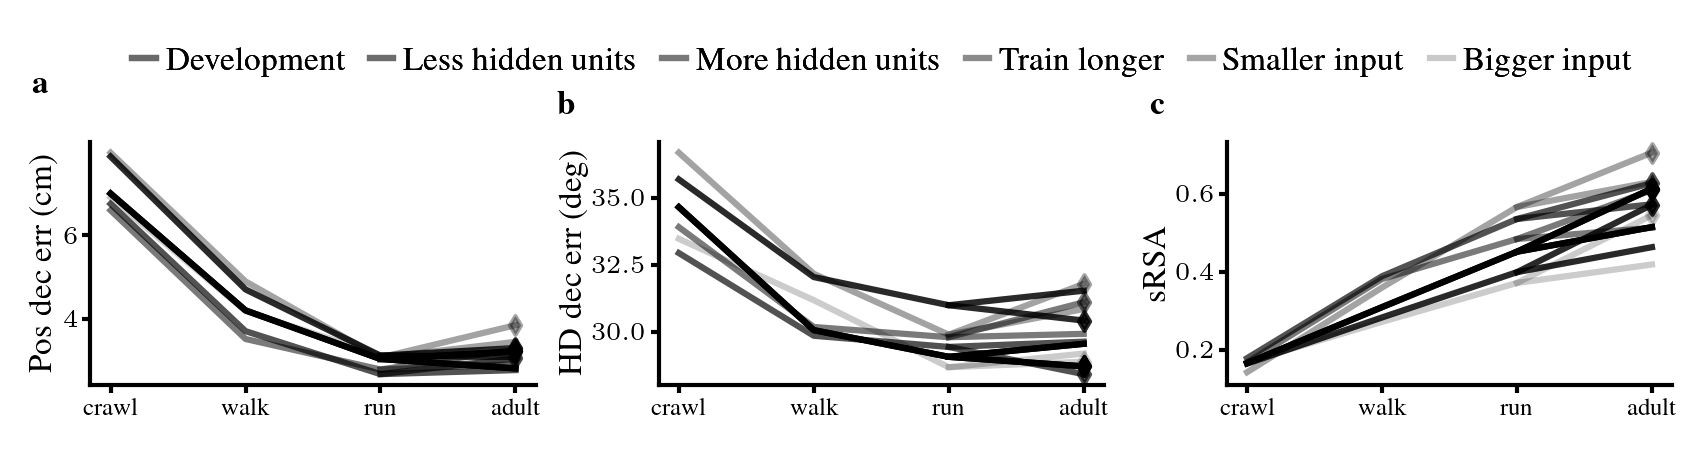

In [39]:
import matplotlib.lines as mlines

plt.style.use(os.path.join(BASE_DIR, 'matplotlib_style.mplstyle'))
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{times}'
plt.rcParams['font.family'] = 'serif'

fig, axs = plt.subplots(
    2, 3, figsize=(5.5, 1.3),
    height_ratios=(0.001, 1),
    dpi=300,
    # layout="constrained"
)

gs = axs.flat[0].get_gridspec()
for i in range(3):
    axs.flat[i].remove()
ax_g = fig.add_subplot(gs[0, :])
gs_c = ax_g.get_subplotspec()
fig.delaxes(ax_g)

nested_gs = gs_c.subgridspec(1,1, wspace=0, hspace=0)
ax = fig.add_subplot(nested_gs[0])
ax.set_axis_off()

alphas = np.linspace(1, alpha_low, len(labels_compare))
lines_legend = []
for idx, l in enumerate(labels_compare):
    lines_legend.append(
        mlines.Line2D([], [], color='dimgray', linestyle='-', label=l, alpha=alphas[idx])
    )
l = ax.legend(
    handles=lines_legend,
    title_fontsize=8,
    loc='upper center', ncol=len(labels_compare), frameon=False, handlelength=0.7,
    fontsize=8, borderpad=0, labelspacing=0.5, handletextpad=0.3,
    columnspacing=0.8
)
l.get_title().set_ha("left")
plt.setp(l.get_title(), horizontalalignment='left')
ax.add_artist(l)

###############################################################
### PLOT 1 ##################################################
ax = axs.flat[3]

ax.annotate(
    r'\textbf{a}', xy=(0, 1), xycoords='axes fraction',
    xytext=(-10, 10), textcoords='offset points',
    ha='right', va='bottom'
)

m = [np.mean(p) for p in poserr_all_dev]
ax.plot(range(len(m)), m, c='black')
ax.plot([2,3], [m[-2], np.mean(poserr_all_dev_gc)], c='black')
ax.scatter(3, np.mean(poserr_all_dev_gc), c='black', marker='d', s=10)

for idx, alpha in enumerate(np.linspace(1, alpha_low, len(labels_compare))):
    m = [np.mean(p) for p in poserr_all_compare[idx]]
    ax.plot(range(len(m)), m, c='black', alpha=alpha, zorder=-10)
    ax.plot([2,3], [m[-2], np.mean(poserr_all_compare_gc[idx])], c='black', alpha=alpha)
    ax.scatter(3, np.mean(poserr_all_compare_gc[idx]), c='black', alpha=alpha, marker='d', s=10)

ax.set_xticks(range(len(poserr_all_dev)), LABELS_DEV)
ax.set_ylabel('Pos dec err (cm)')
ax.set_yticks([4, 6])
ax.spines[['right', 'top']].set_visible(False)


###############################################################
### PLOT 2 ####################################################
ax = axs.flat[4]
ax.annotate(
    r'\textbf{b}', xy=(0, 1), xycoords='axes fraction',
    xytext=(-20, 5), textcoords='offset points',
    ha='right', va='bottom'
)

m = [np.mean(y) for y in hderr_all_dev]
ax.plot(range(len(m)), m, c='black')
ax.plot([2,3], [m[-2], np.mean(hderr_all_dev_gc)], c='black')
ax.scatter(3, np.mean(hderr_all_dev_gc), c='black', marker='d', s=10)

for idx, alpha in enumerate(np.linspace(1, alpha_low, len(labels_compare))):
    m = [np.mean(p) for p in hderr_all_compare[idx]]
    ax.plot(range(len(m)), m, c='black', alpha=alpha, zorder=-10)
    ax.plot([2,3], [m[-2], np.mean(hderr_all_compare_gc[idx])], c='black', alpha=alpha)
    ax.scatter(3, np.mean(hderr_all_compare_gc[idx]), c='black', alpha=alpha, marker='d', s=10)

ax.set_ylabel('HD dec err (deg)')
ax.set_xticks(range(len(poserr_all_dev)), LABELS_DEV)
# ax.set_ylim([30, 35])
ax.spines[['right', 'top']].set_visible(False)


###############################################################
### PLOT 3 ####################################################
ax = axs.flat[5]
ax.annotate(
    r'\textbf{c}', xy=(0, 1), xycoords='axes fraction',
    xytext=(-15, 5), textcoords='offset points',
    ha='right', va='bottom'
)
ax.set_ylabel('sRSA')

m = [np.mean(y) for y in sRSA_dev]
ax.plot(m, c='black', label='Modeled')
ax.scatter(3, np.mean(sRSA_dev_gc), c='black', marker='d', s=10)
ax.plot([2,3], [m[-2], np.mean(sRSA_dev_gc)], c='black')

for idx, alpha in enumerate(np.linspace(1, alpha_low, len(labels_compare))):
    m = [np.mean(p) for p in sRSA_compare[idx]]
    ax.plot(range(len(m)), m, c='black', alpha=alpha, zorder=-10)
    ax.plot([2,3], [m[-2], np.mean(sRSA_compare_gc[idx])], c='black', alpha=alpha)
    ax.scatter(3, np.mean(sRSA_compare_gc[idx]), c='black', alpha=alpha, marker='d', s=10)

ax.set_xticks(range(len(sRSA_dev)), LABELS_DEV)
ax.set_yticks([0.2,0.4,0.6])
ax.set_ylim(bottom=0.11)
ax.spines[['right', 'top']].set_visible(False)
    
plt.tight_layout(w_pad=0.4, pad=0, h_pad=1.2)
plt.savefig(
    os.path.join(BASE_DIR, 'paper_figures', 'compare_param_sweep.pdf'),
    dpi=300, bbox_inches='tight', pad_inches=0.02
)
plt.show()

# End